# 🧠 Alzheimer's Disease Progression Prediction
## CNN + LSTM on Longitudinal Brain MRI

**Goal:** Predict whether a patient's Mild Cognitive Impairment (MCI) will remain stable or convert to Alzheimer's Disease (AD) using a sequence of brain MRI scans over time.

**Architecture:**
- **3D CNN** — extracts spatial features from each MRI volume
- **LSTM** — models how those features evolve across timepoints
- **Output** — binary: Stable MCI (0) vs Converting to AD (1)

---


## ✅ Step 1 — Check GPU

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    print(f"✅ GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU found — go to Runtime → Change runtime type → T4 GPU")
    print("   Training will be slow on CPU.")


⚠️  No GPU found — go to Runtime → Change runtime type → T4 GPU
   Training will be slow on CPU.


## 📦 Step 2 — Install dependencies

In [ ]:
# nibabel  : read NIfTI MRI files
# nilearn  : brain image processing
# scikit-learn : metrics and data splitting
%pip install nibabel nilearn scikit-learn --quiet
print("✅ All packages installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 33.2 MB/s eta 0:00:00
✅ All packages installed


## 🏗️ Step 3 — Define the CNN + LSTM model

The **CNN3D** encoder compresses each MRI volume (64×64×64) into a 256-d feature vector.
The **LSTM** reads those vectors in time order to capture disease trajectory.


In [ ]:
import torch
import torch.nn as nn


class CNN3D(nn.Module):
    """3D CNN that encodes one MRI volume into a feature vector."""

    def __init__(self, in_channels=1, feature_dim=256):
        super().__init__()
        self.encoder = nn.Sequential(
            # Block 1: 64³ → 32³
            nn.Conv3d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32), nn.ReLU(inplace=True), nn.MaxPool3d(2),
            # Block 2: 32³ → 16³
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64), nn.ReLU(inplace=True), nn.MaxPool3d(2),
            # Block 3: 16³ → 8³
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm3d(128), nn.ReLU(inplace=True), nn.MaxPool3d(2),
            # Global average pool → (batch, 128)
            nn.AdaptiveAvgPool3d(1), nn.Flatten(),
        )
        self.fc = nn.Sequential(
            nn.Linear(128, feature_dim), nn.ReLU(inplace=True), nn.Dropout(0.3),
        )

    def forward(self, x):
        return self.fc(self.encoder(x))


class CNNLSTM(nn.Module):
    """CNN per timepoint + LSTM across timepoints → progression classifier."""

    def __init__(self, in_channels=1, feature_dim=256,
                 hidden_dim=128, num_layers=2, num_classes=2, dropout=0.4):
        super().__init__()
        self.cnn = CNN3D(in_channels, feature_dim)
        self.lstm = nn.LSTM(
            input_size=feature_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(64, num_classes),
        )

    def forward(self, x):
        # x: (batch, timepoints, 1, D, H, W)
        B, T, C, D, H, W = x.shape
        feats = self.cnn(x.view(B * T, C, D, H, W))   # (B*T, feature_dim)
        feats = feats.view(B, T, -1)                   # (B, T, feature_dim)
        lstm_out, _ = self.lstm(feats)                 # (B, T, hidden_dim)
        return self.classifier(lstm_out[:, -1, :])     # (B, num_classes)


# ── Quick shape test ──────────────────────────────────────────────────────────
model = CNNLSTM().to(device)
dummy = torch.randn(2, 3, 1, 64, 64, 64).to(device)
out   = model(dummy)

print(f"Input  shape : {dummy.shape}  →  (batch, timepoints, channel, D, H, W)")
print(f"Output shape : {out.shape}  →  (batch, num_classes)")
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")


Input  shape : torch.Size([2, 3, 1, 64, 64, 64])  →  (batch, timepoints, channel, D, H, W)
Output shape : torch.Size([2, 2])  →  (batch, num_classes)
Trainable parameters: 649,154


## 📁 Step 4a — Download ADNI zips from Google Drive



In [ ]:
import os, zipfile, subprocess

# ──  Google Drive file IDs  ────────────────────────────────────
# From sharing link: https://drive.google.com/file/d/FILE_ID_HERE/view
# https://drive.google.com/file/d/1Uhgpyaur4u7YqtUPswwc-W7GIQlkp5yI/view?usp=sharing
# https://drive.google.com/file/d/1BKxhiruzcnoZcTehNeyd-gM3kAxEIZgI/view?usp=drive_link
FILE_ID_1 = "1Uhgpyaur4u7YqtUPswwc-W7GIQlkp5yI"   # zip 1 (json + mci_to_mci + mci_to_ad)
FILE_ID_2 = "1BKxhiruzcnoZcTehNeyd-gM3kAxEIZgI"   # zip 2 (mci_to_ad)
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs("/content/adni_raw", exist_ok=True)
%pip install gdown --quiet

import gdown

def download_and_extract(file_id, zip_name):
    out_path = f"/content/{zip_name}"
    print(f"Downloading {zip_name} ...")
    gdown.download(id=file_id, output=out_path, quiet=False)

    print(f"Extracting {zip_name} ...")
    with zipfile.ZipFile(out_path, "r") as zf:
        zf.extractall("/content/adni_raw")

    # Delete zip after extraction to free up disk space
    os.remove(out_path)
    print(f"  Done. Zip deleted to free space.\n")

download_and_extract(FILE_ID_1, "adni_zip1.zip")
download_and_extract(FILE_ID_2, "adni_zip2.zip")

# ── Showing what was extracted ───────────────────────────────────────────────────
print("Extracted folder structure:")
for root, dirs, fnames in os.walk("/content/adni_raw"):
    depth = root.replace("/content/adni_raw", "").count(os.sep)
    if depth > 3:
        continue
    indent = "  " * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth >= 2:
        for fn in sorted(fnames)[:3]:
            print(f"{indent}  {fn}")
        if len(fnames) > 3:
            print(f"{indent}  ... ({len(fnames)} files total)")

# ── Check available disk space ────────────────────────────────────────────────
result = subprocess.run(["df", "-h", "/content"], capture_output=True, text=True)
print("\nDisk usage:")
print(result.stdout)


Downloading...
From (original): https://drive.google.com/uc?id=1Uhgpyaur4u7YqtUPswwc-W7GIQlkp5yI
From (redirected): https://drive.google.com/uc?id=1Uhgpyaur4u7YqtUPswwc-W7GIQlkp5yI&confirm=t&uuid=f9933adf-b9dd-4928-a892-ce95737b19c9
To: /content/adni_zip1.zip
100%|██████████| 2.13G/2.13G [00:33<00:00, 64.3MB/s]


Extracting adni_zip1.zip ...
  Done. Zip deleted to free space.



Downloading...
From (original): https://drive.google.com/uc?id=1BKxhiruzcnoZcTehNeyd-gM3kAxEIZgI
From (redirected): https://drive.google.com/uc?id=1BKxhiruzcnoZcTehNeyd-gM3kAxEIZgI&confirm=t&uuid=bc7b5444-3b8f-40bd-a6b3-fab575949f9e
To: /content/adni_zip2.zip
100%|██████████| 160M/160M [00:04<00:00, 35.6MB/s]


Extracting adni_zip2.zip ...
  Done. Zip deleted to free space.

Extracted folder structure:
adni_raw/
  ADNI_NIFTI/
    MCI_to_AD/
      301____________mprage_sens.nii.gz
      3_mprage_repeat.nii.gz
      401____________mprage.nii.gz
      ... (109 files total)
    MCI_to_MCI/
      301____________mprage_3dtf.nii.gz
      301_mprage.nii.gz
      3_mprage.nii.gz
      ... (109 files total)

Disk usage:
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   24G   85G  22% /



In [ ]:
# ── Scan all .nii.gz files and auto-assign labels from folder names ───────────
#
# Folder name rules (case-insensitive):
#   contains "mci_to_ad"  →  label 1  (converting)
#   contains "mci_to_mci" →  label 0  (stable)
import glob
all_scans = []   # list of (filepath, label)

for nii_path in sorted(glob.glob("/content/adni_raw/**/*.nii.gz", recursive=True)):
    parts = nii_path.lower()
    if "mci_to_ad" in parts:
        label = 1
    elif "mci_to_mci" in parts:
        label = 0
    else:
        print(f"  Skipping (unknown label): {nii_path}")
        continue
    all_scans.append((nii_path, label))

stable    = [(p, l) for p, l in all_scans if l == 0]
converting = [(p, l) for p, l in all_scans if l == 1]

print(f"Total scans found    : {len(all_scans)}")
print(f"  Stable MCI (0)     : {len(stable)}")
print(f"  Converting → AD (1): {len(converting)}")

if len(all_scans) == 0:
    print("\n⚠️  No .nii.gz files found! Check the folder structure printout above.")
    print("   Make sure both zips extracted correctly into /content/adni_raw/")
else:
    print(f"\nFirst stable scan    : {stable[0][0]}")
    print(f"First converting scan: {converting[0][0]}")


Total scans found    : 218
  Stable MCI (0)     : 109
  Converting → AD (1): 109

First stable scan    : /content/adni_raw/ADNI_NIFTI/MCI_to_MCI/301____________mprage_3dtf.nii.gz
First converting scan: /content/adni_raw/ADNI_NIFTI/MCI_to_AD/301____________mprage_sens.nii.gz


In [ ]:
# ── Group scans by subject ID ─────────────────────────────────────────────────
#
# ADNI filenames typically look like:
#   037_S_0501_MCI_to_AD_bl_reg_brain.nii.gz
#   sub-ADNI037S0501_ses-M00_T1w.nii.gz
#
# We extract the subject ID as the first token (split on _ or -)
# then group all timepoints for that subject together.
#

import re
from collections import defaultdict

def parse_subject_id(filepath):
    fname = os.path.basename(filepath)
    # full filename (minus extension) as unique ID
    return fname.replace(".nii.gz", "").replace(".nii", "")

subjects = defaultdict(lambda: {"scans": [], "label": None})

for path, label in all_scans:
    sid = parse_subject_id(path)
    subjects[sid]["scans"].append(path)
    if subjects[sid]["label"] is None:
        subjects[sid]["label"] = label


subject_list = list(subjects.items())
print(f"Unique subjects: {len(subject_list)}")
print(f"  Stable MCI     : {sum(1 for _, v in subject_list if v['label'] == 0)}")
print(f"  Converting → AD: {sum(1 for _, v in subject_list if v['label'] == 1)}")
print()

# Show a few examples
for sid, info in subject_list[:4]:
    print(f"  {sid}  label={info['label']}  scans={len(info['scans'])}")
    for p in info['scans'][:2]:
        print(f"    {os.path.basename(p)}")


Unique subjects: 218
  Stable MCI     : 109
  Converting → AD: 109

  301____________mprage_sens  label=1  scans=1
    301____________mprage_sens.nii.gz
  3_mprage_repeat  label=1  scans=1
    3_mprage_repeat.nii.gz
  401____________mprage  label=1  scans=1
    401____________mprage.nii.gz
  401_mprage  label=1  scans=1
    401_mprage.nii.gz


## 📊 Step 4b — ADNI Dataset class

A loader reads  `.nii.gz` files, normalises them, and pads sequences to a fixed length.


In [ ]:
import numpy as np
import nibabel as nib
import torch
from torch.utils.data import Dataset, DataLoader, random_split

VOL_SIZE       = 32    # CPU mode: 32³ is much faster on CPU
MAX_TIMEPOINTS = 1     # one scan per patient in this dataset
BATCH_SIZE     = 2     # smaller batch for CPU


def resize_volume(vol, target=(32, 32, 32)):
    """Centre-crop or zero-pad each axis to reach target shape."""
    out = np.zeros(target, dtype=np.float32)
    src_slices, dst_slices = [], []
    for s_len, t_len in zip(vol.shape, target):
        if s_len >= t_len:
            start = (s_len - t_len) // 2
            src_slices.append(slice(start, start + t_len))
            dst_slices.append(slice(0, t_len))
        else:
            pad = (t_len - s_len) // 2
            src_slices.append(slice(0, s_len))
            dst_slices.append(slice(pad, pad + s_len))
    out[tuple(dst_slices)] = vol[tuple(src_slices)]
    return out


def load_nifti(path, target_shape=(32, 32, 32)):
    """Load a NIfTI file, normalise to [0,1], resize."""
    img  = nib.load(path)
    data = np.squeeze(img.get_fdata()).astype(np.float32)
    if data.ndim == 4:
        data = data[..., 0]
    dmin, dmax = data.min(), data.max()
    if dmax > dmin:
        data = (data - dmin) / (dmax - dmin)
    return resize_volume(data, target_shape)


class ADNIRealDataset(Dataset):
    def __init__(self, subject_items, max_timepoints=1,
                 vol_size=32, augment=False):
        self.subjects = subject_items
        self.T        = max_timepoints
        self.shape    = (vol_size,) * 3
        self.augment  = augment

    def __len__(self):
        return len(self.subjects)

    def __getitem__(self, idx):
        sid, info  = self.subjects[idx]
        label      = info["label"]
        scan_paths = sorted(info["scans"])[: self.T]

        padded = np.zeros((self.T, *self.shape), dtype=np.float32)
        mask   = np.zeros(self.T, dtype=np.float32)

        for i, path in enumerate(scan_paths):
            try:
                vol = load_nifti(path, self.shape)
                if self.augment and np.random.rand() > 0.5:
                    vol = np.flip(vol, axis=0).copy()
                padded[i] = vol
                mask[i]   = 1.0
            except Exception as e:
                print(f"  ⚠️  Could not load {path}: {e}")

        volume_tensor = torch.from_numpy(padded).unsqueeze(1)  # (T,1,D,H,W)
        return volume_tensor, torch.tensor(label, dtype=torch.long), torch.from_numpy(mask)


# ── Train / val / test split ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

labels_for_split = [v["label"] for _, v in subject_list]

train_items, temp_items, _, temp_labels = train_test_split(
    subject_list, labels_for_split,
    test_size=0.30, stratify=labels_for_split, random_state=42
)
val_items, test_items = train_test_split(
    temp_items, test_size=0.50,
    stratify=temp_labels, random_state=42
)

train_ds = ADNIRealDataset(train_items, MAX_TIMEPOINTS, VOL_SIZE, augment=True)
val_ds   = ADNIRealDataset(val_items,   MAX_TIMEPOINTS, VOL_SIZE, augment=False)
test_ds  = ADNIRealDataset(test_items,  MAX_TIMEPOINTS, VOL_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f"Subjects — Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

# ── Sanity check: load one batch ──────────────────────────────────────────────
print("\nLoading one batch to verify shapes...")
vols, lbls, masks = next(iter(train_loader))
print(f"  volumes : {vols.shape}   (B, T, C, D, H, W)")
print(f"  labels  : {lbls.tolist()}")
print(f"  masks   : {masks.tolist()}")
print("\n✅ Real data pipeline ready!")

Subjects — Train: 152  Val: 33  Test: 33

Loading one batch to verify shapes...
  volumes : torch.Size([2, 1, 1, 32, 32, 32])   (B, T, C, D, H, W)
  labels  : [0, 1]
  masks   : [[1.0], [1.0]]

✅ Real data pipeline ready!


## 🚀 Step 5 — Train

- **Loss:** Cross-entropy with a 2× weight on the positive class (converting), since those cases are rarer.
- **Gradient clipping** stabilises LSTM training.
- **Best checkpoint** is saved automatically based on validation AUC.


In [ ]:
import time, os
from sklearn.metrics import accuracy_score, roc_auc_score

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, preds_all, labels_all = 0.0, [], []
    for batch_idx, (vols, labels, _) in enumerate(loader):
        vols, labels = vols.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(vols)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * vols.size(0)
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
        if (batch_idx + 1) % 5 == 0:
            print(".", end="", flush=True)
    print()
    return total_loss / len(loader.dataset), accuracy_score(labels_all, preds_all)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, preds_all, labels_all, probs_all = 0.0, [], [], []
    for vols, labels, _ in loader:
        vols, labels = vols.to(device), labels.to(device)
        logits = model(vols)
        total_loss += criterion(logits, labels).item() * vols.size(0)
        probs_all.extend(torch.softmax(logits, 1)[:, 1].cpu().numpy())
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
    auc = roc_auc_score(labels_all, probs_all) if len(set(labels_all)) > 1 else 0.0
    return total_loss / len(loader.dataset), accuracy_score(labels_all, preds_all), auc, labels_all, preds_all


# ── Hyperparams ───────────────────────────────────────────────────────────────
EPOCHS = 15
LR     = 1e-4

model     = CNNLSTM().to(device)
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 2.0]).to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

os.makedirs("results", exist_ok=True)
best_val_auc = 0.0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_auc": []}

print(f"Training on: {device.upper()}")
print(f"Epochs: {EPOCHS}  |  Batch: {BATCH_SIZE}  |  Vol: {VOL_SIZE}³")
print(f"{'Epoch':>6}  {'Tr Loss':>8}  {'Tr Acc':>7}  {'Vl Loss':>8}  {'Vl Acc':>7}  {'Vl AUC':>7}  {'Time':>7}")
print("-" * 68)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    print(f"Epoch {epoch:02d}/{EPOCHS} ", end="")
    tr_loss, tr_acc              = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc, vl_auc, *_ = evaluate(model, val_loader, criterion)
    scheduler.step(vl_auc)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["val_auc"].append(vl_auc)

    flag = ""
    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        torch.save(model.state_dict(), "results/best_model.pth")
        flag = " ✓ saved"

    elapsed   = time.time() - t0
    remaining = elapsed * (EPOCHS - epoch)
    print(f"{epoch:>6}  {tr_loss:>8.4f}  {tr_acc:>7.3f}  {vl_loss:>8.4f}  "
          f"{vl_acc:>7.3f}  {vl_auc:>7.3f}  {elapsed:>6.1f}s{flag}")
    print(f"         Est. remaining: {remaining/60:.1f} min")

print(f"\nDone — best val AUC: {best_val_auc:.4f}")

Training on: CPU
Epochs: 15  |  Batch: 2  |  Vol: 32³
 Epoch   Tr Loss   Tr Acc   Vl Loss   Vl Acc   Vl AUC     Time
--------------------------------------------------------------------
Epoch 01/15 ...............
     1    0.6945    0.474    0.6926    0.515    0.368    73.0s ✓ saved
         Est. remaining: 17.0 min
Epoch 02/15 ...............
     2    0.6918    0.507    0.6845    0.515    0.676    60.0s ✓ saved
         Est. remaining: 13.0 min
Epoch 03/15 ...............
     3    0.6887    0.474    0.6815    0.515    0.614    59.5s
         Est. remaining: 11.9 min
Epoch 04/15 ...............
     4    0.6812    0.507    0.6755    0.515    0.636    58.4s
         Est. remaining: 10.7 min
Epoch 05/15 ...............
     5    0.6793    0.500    0.6668    0.515    0.658    68.7s
         Est. remaining: 11.4 min
Epoch 06/15 ...............
     6    0.6805    0.500    0.6688    0.515    0.643    60.1s
         Est. remaining: 9.0 min
Epoch 07/15 ...............
     7    0.6793    0

## 📈 Step 6 — Plot training curves

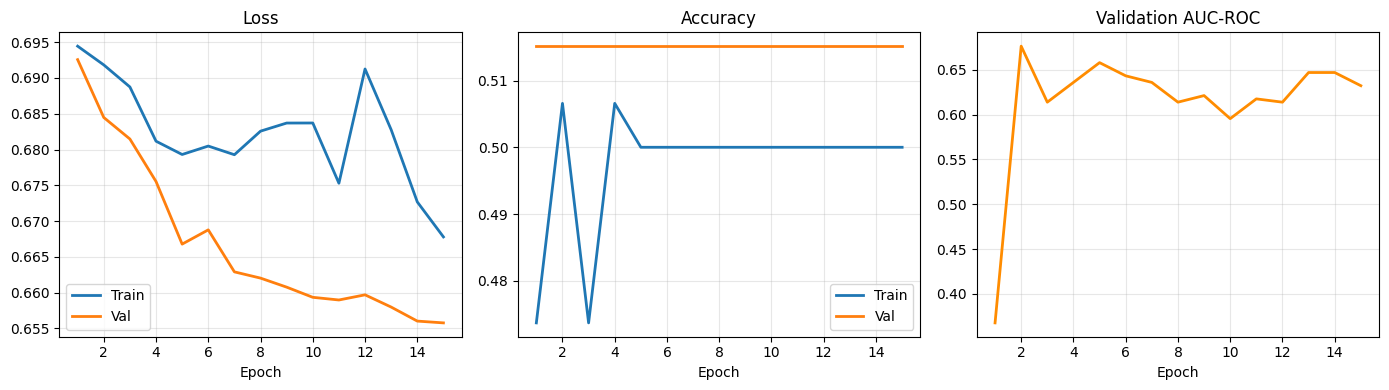

Saved → results/training_curves.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 4))
gs  = gridspec.GridSpec(1, 3, figure=fig)
epochs_range = range(1, EPOCHS + 1)

ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs_range, history["train_loss"], label="Train", linewidth=2)
ax1.plot(epochs_range, history["val_loss"],   label="Val",   linewidth=2)
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.plot(epochs_range, history["train_acc"], label="Train", linewidth=2)
ax2.plot(epochs_range, history["val_acc"],   label="Val",   linewidth=2)
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[2])
ax3.plot(epochs_range, history["val_auc"], color="darkorange", linewidth=2)
ax3.set_title("Validation AUC-ROC"); ax3.set_xlabel("Epoch"); ax3.grid(alpha=0.3)

fig.tight_layout()
plt.savefig("results/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/training_curves.png")


## 🧪 Step 7 — Test set evaluation

Test Accuracy : 0.4848
Test AUC-ROC  : 0.7279

                  precision    recall  f1-score   support

      Stable MCI       0.00      0.00      0.00        17
Converting to AD       0.48      1.00      0.65        16

        accuracy                           0.48        33
       macro avg       0.24      0.50      0.33        33
    weighted avg       0.24      0.48      0.32        33



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


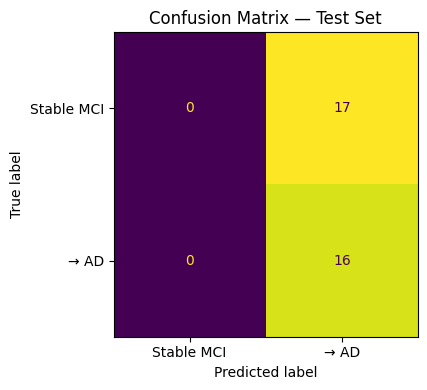

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

model.load_state_dict(torch.load("results/best_model.pth", map_location=device))
_, te_acc, te_auc, y_true, y_pred = evaluate(model, test_loader, criterion)

print(f"Test Accuracy : {te_acc:.4f}")
print(f"Test AUC-ROC  : {te_auc:.4f}")
print()
print(classification_report(y_true, y_pred, target_names=["Stable MCI", "Converting to AD"]))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Stable MCI", "→ AD"]).plot(ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

Best threshold (from val set): 0.515
Test AUC-ROC               : 0.7279
Test Accuracy (tuned)      : 0.7273

                  precision    recall  f1-score   support

      Stable MCI       0.83      0.59      0.69        17
Converting to AD       0.67      0.88      0.76        16

        accuracy                           0.73        33
       macro avg       0.75      0.73      0.72        33
    weighted avg       0.75      0.73      0.72        33



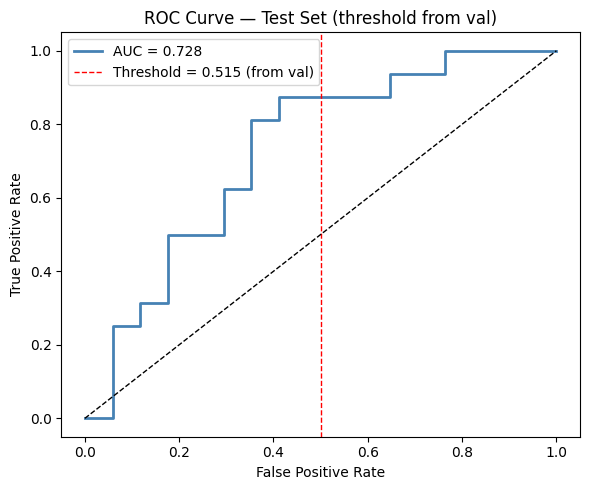

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("results/best_model.pth", map_location=device))
model.eval()

# ── Step 1: find best threshold on VALIDATION set ────────────────────────────
val_probs, val_true = [], []
with torch.no_grad():
    for vols, labels, _ in val_loader:
        logits = model(vols.to(device))
        val_probs.extend(torch.softmax(logits, 1)[:, 1].cpu().numpy())
        val_true.extend(labels.numpy())

fpr, tpr, thresholds = roc_curve(val_true, val_probs)
best_idx       = (tpr - fpr).argmax()
best_threshold = thresholds[best_idx]
print(f"Best threshold (from val set): {best_threshold:.3f}")

# ── Step 2: apply that threshold to TEST set ──────────────────────────────────
test_probs, test_true = [], []
with torch.no_grad():
    for vols, labels, _ in test_loader:
        logits = model(vols.to(device))
        test_probs.extend(torch.softmax(logits, 1)[:, 1].cpu().numpy())
        test_true.extend(labels.numpy())

y_pred_best = (np.array(test_probs) >= best_threshold).astype(int)
auc = roc_auc_score(test_true, test_probs)

print(f"Test AUC-ROC               : {auc:.4f}")
print(f"Test Accuracy (tuned)      : {accuracy_score(test_true, y_pred_best):.4f}")
print()
print(classification_report(test_true, y_pred_best,
      target_names=["Stable MCI", "Converting to AD"]))

# ── ROC curve ─────────────────────────────────────────────────────────────────
fpr_t, tpr_t, _ = roc_curve(test_true, test_probs)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_t, tpr_t, color="steelblue", linewidth=2, label=f"AUC = {auc:.3f}")
ax.axvline(x=fpr[best_idx], color="red", linestyle="--", linewidth=1,
           label=f"Threshold = {best_threshold:.3f} (from val)")
ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set (threshold from val)")
ax.legend()
plt.tight_layout()
plt.savefig("results/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 🔍 Step 8 — Grad-CAM: which brain regions matter?

Grad-CAM highlights the voxels the CNN paid most attention to.
On real ADNI data you should see **hippocampus and entorhinal cortex** highlighted — the regions most affected by Alzheimer's.


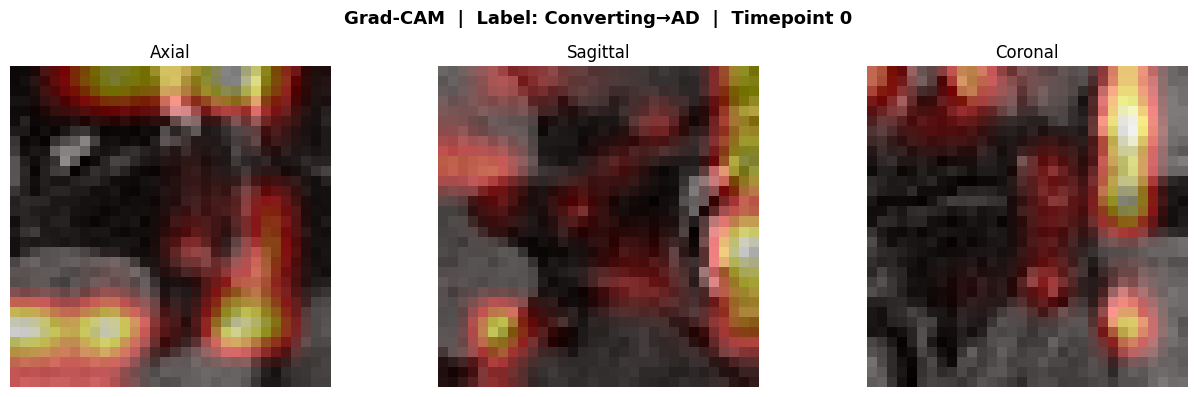

Saved → results/gradcam.png


In [ ]:
class GradCAM3D:
    def __init__(self, model, target_layer):
        self.model = model
        self._grads = None
        self._acts  = None
        target_layer.register_forward_hook(lambda m, i, o: setattr(self, "_acts", o.detach()))
        target_layer.register_full_backward_hook(lambda m, gi, go: setattr(self, "_grads", go[0].detach()))

    def generate(self, volumes, class_idx=1, timepoint=0):
        # cuDNN LSTM backward requires training mode — switch back after
        self.model.train()
        volumes = volumes.requires_grad_(True)
        logits  = self.model(volumes)
        self.model.zero_grad()
        logits[0, class_idx].backward()
        self.model.eval()

        grads = self._grads[timepoint]                   # (C, d, h, w)
        acts  = self._acts[timepoint]
        weights = grads.mean(dim=(1, 2, 3))
        cam = torch.einsum("c,cdhw->dhw", weights, acts)
        cam = torch.relu(cam).unsqueeze(0).unsqueeze(0)
        cam = torch.nn.functional.interpolate(
            cam, size=volumes.shape[-3:], mode="trilinear", align_corners=False
        ).squeeze()
        cam = cam.cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)


# Attach to last Conv3d in the encoder (index 8 = Block 3's Conv3d)
gradcam = GradCAM3D(model, model.cnn.encoder[8])

# Get one sample
vols_sample, label_sample, _ = train_ds[0]
vols_input = vols_sample.unsqueeze(0).to(device)   # (1, T, 1, D, H, W)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f"Grad-CAM  |  Label: {'Converting→AD' if label_sample==1 else 'Stable MCI'}  |  Timepoint 0",
             fontsize=13, fontweight="bold")

cam = gradcam.generate(vols_input.clone(), class_idx=1, timepoint=0)
mri = vols_sample[0, 0].numpy()   # (D, H, W)
D, H, W = mri.shape

for ax, (plane, sl_mri, sl_cam) in zip(axes, [
    ("Axial",    mri[D//2, :, :], cam[D//2, :, :]),
    ("Sagittal", mri[:, :, W//2], cam[:, :, W//2]),
    ("Coronal",  mri[:, H//2, :], cam[:, H//2, :]),
]):
    ax.imshow(sl_mri, cmap="gray",   origin="lower")
    ax.imshow(sl_cam, cmap="hot",    origin="lower", alpha=0.45)
    ax.set_title(plane); ax.axis("off")

plt.tight_layout()
plt.savefig("results/gradcam.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/gradcam.png")


## 💾 Step 9 — Download results from Colab

In [ ]:
from google.colab import files
import zipfile, os

# Zip everything in results/
with zipfile.ZipFile("alzheimer_results.zip", "w") as zf:
    for fname in os.listdir("results"):
        zf.write(os.path.join("results", fname), fname)

files.download("alzheimer_results.zip")
print("Download started — check your browser's Downloads folder.")
